In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df = pd.read_csv('github_issues_severity.csv')
print(f"Shape : {df.shape}")
df.head()

Shape : (114073, 2)


,text,severity
0,Output file size with -s or -g Was: http://bit...,Low
1,Create a php API and demo page youtube-dl is o...,Low
2,"integrate template ""special sequences"" in help...",Low
3,"Add a path option to --keep-video Hey there,\n...",Low
4,add support for picasaweb.google.com video cli...,Low


In [25]:
print('Dataset Info')
df.info()
print('\nMissing Values')
print(df.isnull().sum())
print('\nDuplicate Values')
print(f"Duplicate rows: {df.duplicated().sum()}")

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114073 entries, 0 to 114072
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   text      114073 non-null  object
 1   severity  114073 non-null  object
dtypes: object(2)
memory usage: 1.7+ MB

Missing Values
text        0
severity    0
dtype: int64

Duplicate Values
Duplicate rows: 8


In [26]:
print(f'Columns : {df.columns.tolist()}')
print(f'Sample data: {df.sample(5)}')

Columns : ['text', 'severity']
Sample data:                                                      text severity
1106    Problem Accessing Histogram Elements in Androi...   Medium
98046   TextField context menu should block user inter...   Medium
100914  AppBar scrolled under state not working when s...   Medium
70229   Missed autovectorization for slice.iter.fold, ...      Low
34597   Pass arguments to ffmpeg  \r\n## Checklist\r\n...      Low


Distribusi Label
severity
Medium      61419
Low         45195
Critical     7459
Name: count, dtype: int64

Persentase: severity
Medium      53.841838
Low         39.619367
Critical     6.538795
Name: proportion, dtype: float64


C:\Users\zahra\AppData\Local\Temp\ipykernel_48100\1387982006.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x='severity', order=df['severity'].value_counts().index, palette='viridis')


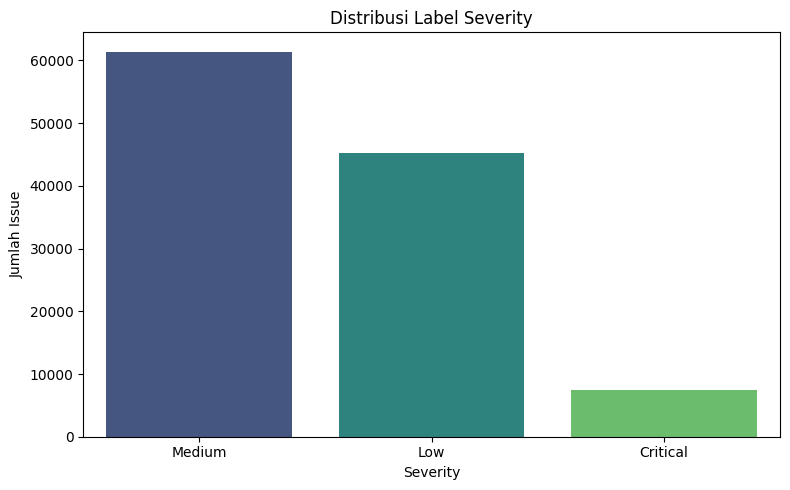

In [27]:
print(f'Distribusi Label')
print(df['severity'].value_counts())
print(f'\nPersentase: {df["severity"].value_counts(normalize=True) * 100}')

plt.figure(figsize=(8,5))
sns.countplot(data = df, x='severity', order=df['severity'].value_counts().index, palette='viridis')
plt.title('Distribusi Label Severity')
plt.xlabel('Severity')
plt.ylabel('Jumlah Issue')
plt.tight_layout()
plt.show()

In [34]:
df['text_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

print('Statistik Panjang Teks (Karakter)')
df['text_length'].describe()

Statistik Panjang Teks (Karakter)


count    114073.000000
mean       2595.542188
std        6067.476715
min          10.000000
25%         735.000000
50%        1376.000000
75%        2547.000000
max      255724.000000
Name: text_length, dtype: float64

In [35]:
print('\nStatistik Jumlah Kata')
df['word_count'].describe()


Statistik Jumlah Kata


count    114073.000000
mean        268.888300
std         439.252527
min           1.000000
25%          97.000000
50%         177.000000
75%         305.000000
max       26381.000000
Name: word_count, dtype: float64

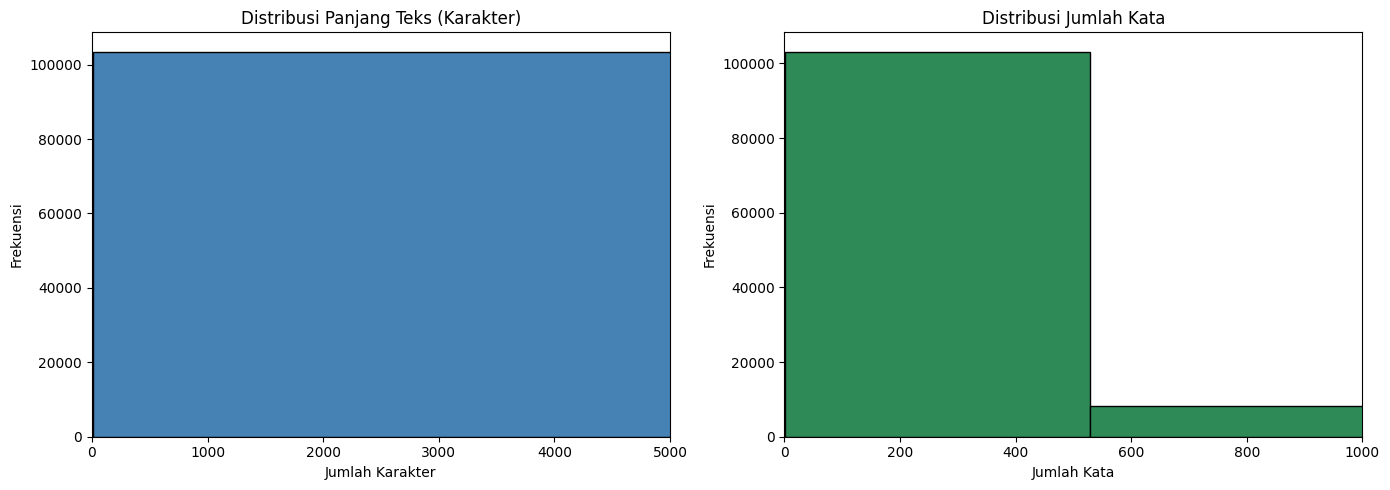

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['text_length'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Distribusi Panjang Teks (Karakter)')
axes[0].set_xlabel('Jumlah Karakter')
axes[0].set_ylabel('Frekuensi')
axes[0].set_xlim(0, 5000)

axes[1].hist(df['word_count'], bins=50, color='seagreen', edgecolor='black')
axes[1].set_title('Distribusi Jumlah Kata')
axes[1].set_xlabel('Jumlah Kata')
axes[1].set_ylabel('Frekuensi')
axes[1].set_xlim(0, 1000)

plt.tight_layout()
plt.show()

C:\Users\zahra\AppData\Local\Temp\ipykernel_48100\3707049501.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='severity', y='text_length',
C:\Users\zahra\AppData\Local\Temp\ipykernel_48100\3707049501.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='severity', y='word_count',


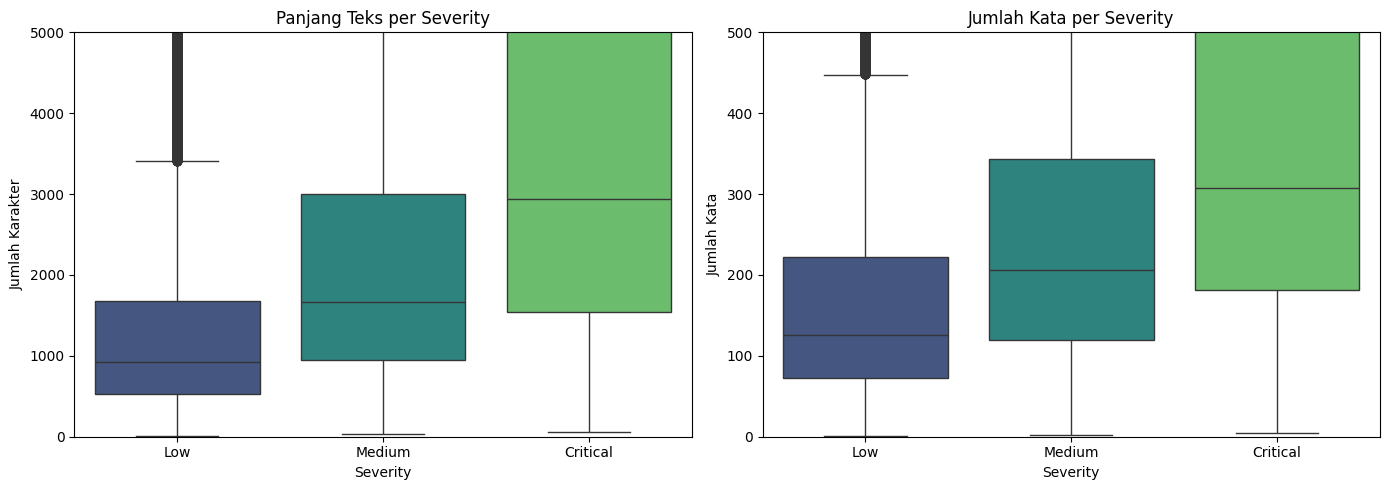

Rata-Rata Panjang Teks Per Severity
          text_length  word_count
severity                         
Critical      5306.72      470.26
Low           1461.79      180.43
Medium        3100.56      309.52


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='severity', y='text_length', 
            order=['Low', 'Medium', 'Critical'], 
            palette='viridis', ax=axes[0])
axes[0].set_title('Panjang Teks per Severity')
axes[0].set_ylim(0, 5000)
axes[0].set_xlabel('Severity')
axes[0].set_ylabel('Jumlah Karakter')

sns.boxplot(data=df, x='severity', y='word_count',
            order=['Low', 'Medium', 'Critical'],
            palette='viridis', ax=axes[1])
axes[1].set_title('Jumlah Kata per Severity')
axes[1].set_ylim(0, 500)
axes[1].set_xlabel('Severity')
axes[1].set_ylabel('Jumlah Kata')

plt.tight_layout()
plt.show()

print("Rata-Rata Panjang Teks Per Severity")
print(df.groupby('severity')[['text_length', 'word_count']].mean().round(2))

In [37]:
# Hapus duplikat
df_clean = df.drop_duplicates()
print(f"Data sebelum: {df.shape[0]} rows")
print(f"Data setelah hapus duplikat: {df_clean.shape[0]} rows")
print(f"Duplikat dihapus: {df.shape[0] - df_clean.shape[0]} rows")

print("\nSummary EDA")
print(f"Total data bersih     : {df_clean.shape[0]:,} rows")
print(f"Missing values        : None")
print(f"Jumlah kelas          : {df_clean['severity'].nunique()} (Low, Medium, Critical)")
print(f"\nDistribusi kelas:")
print(df_clean['severity'].value_counts())
print(f"\nClass imbalance       : YES — Critical hanya {df_clean['severity'].value_counts(normalize=True)['Critical']*100:.1f}%")
print(f"Rata-rata panjang teks: {df_clean['text_length'].mean():.0f} karakter / {df_clean['word_count'].mean():.0f} kata")
print(f"Teks terpendek        : {df_clean['word_count'].min()} kata")
print(f"Teks terpanjang       : {df_clean['word_count'].max():,} kata")

Data sebelum: 114073 rows
Data setelah hapus duplikat: 114065 rows
Duplikat dihapus: 8 rows

Summary EDA
Total data bersih     : 114,065 rows
Missing values        : None
Jumlah kelas          : 3 (Low, Medium, Critical)

Distribusi kelas:
severity
Medium      61415
Low         45191
Critical     7459
Name: count, dtype: int64

Class imbalance       : YES — Critical hanya 6.5%
Rata-rata panjang teks: 2596 karakter / 269 kata
Teks terpendek        : 1 kata
Teks terpanjang       : 26,381 kata


In [33]:
df_clean.to_csv('../data/processed/github_issues_clean.csv', index=False)
print("Data berhasil disimpan ke data/processed/github_issues_clean.csv")
print(f"Shape final: {df_clean.shape}")

Data berhasil disimpan ke data/processed/github_issues_clean.csv
Shape final: (114065, 4)
